In [1]:
# 第4章｜神經網路優化：每次開啟 notebook，先執行這一格（安裝套件、登入 FinLab、開啟資料快取）
%pip install -q finlab==2.0.21 ta-lib==0.8.1
import finlab
from finlab import data

finlab.login()
data.set_storage(data.FileStorage())

Note: you may need to restart the kernel to use updated packages.


已登入（使用快取憑證）。


In [2]:
QUICK_RUN = False  # True：只訓練少量 epoch，只用來快速檢查程式能不能跑

# 神經網路優化

**對應影片**：第 4 章 單元 3、4「NN 優化 Part 1、Part 2」

**和影片的差異**

| 影片（2018） | 新版教材 |
| --- | --- |
| 舊版 Keras | Keras 3：`keras.Input`、`keras.callbacks.EarlyStopping(restore_best_weights=True)` |
| 大盤 15 分 K | 加權指數日 K，特徵與上一個單元相同 |

Part 1：看出過度擬合，學會 Dropout、L2 正則化、Batch Normalization、Early Stopping。
Part 2：比較多組網路設定，用**驗證資料**挑出最好的，再到測試期間回測。

In [3]:
import keras
import pandas as pd
import talib
import finlab.ml.label as label
from finlab.backtest import sim
from keras import layers, regularizers
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

TRADE_STOCK = '0050'
ETF_TAX_RATIO = 0.001
HORIZON = 10
TRAIN_END = '2015-12-31'
TEST_START = '2016-01-01'
RANDOM_STATE = 0

## 準備資料（和上一個單元相同）

In [4]:
PERIODS = [5, 10, 20, 60, 120]
STOCH_SMOOTHING = 3

taiex = pd.DataFrame({
    field: data.get(f'taiex_total_index:{name}')['TAIEX']
    for field, name in [('open', '開盤指數'), ('high', '最高指數'), ('low', '最低指數'), ('close', '收盤指數')]
}).dropna()


def technical_features(ohlc: pd.DataFrame) -> pd.DataFrame:
    high, low, close = ohlc['high'], ohlc['low'], ohlc['close']
    features = {}
    for period in PERIODS:
        slowk, slowd = talib.STOCH(high, low, close, fastk_period=period,
                                   slowk_period=STOCH_SMOOTHING, slowd_period=STOCH_SMOOTHING)
        features[f'rsi_{period}'] = talib.RSI(close, timeperiod=period)
        features[f'k_{period}'] = slowk
        features[f'd_{period}'] = slowd
        features[f'willr_{period}'] = talib.WILLR(high, low, close, timeperiod=period)
        features[f'cci_{period}'] = talib.CCI(high, low, close, timeperiod=period)
        features[f'roc_{period}'] = talib.ROC(close, timeperiod=period)
        features[f'sma_bias_{period}'] = close / talib.SMA(close, timeperiod=period)
        features[f'wma_bias_{period}'] = close / talib.WMA(close, timeperiod=period)
        features[f'atr_ratio_{period}'] = talib.ATR(high, low, close, timeperiod=period) / close
    macd, macd_signal, macd_hist = talib.MACD(close)
    features['macd'] = macd / close
    features['macd_signal'] = macd_signal / close
    features['macd_hist'] = macd_hist / close
    return pd.DataFrame(features)


def forward_return(dates: pd.DatetimeIndex, period: int) -> pd.Series:
    index = pd.MultiIndex.from_product([dates, [TRADE_STOCK]], names=['datetime', 'instrument'])
    return label.return_percentage(index, period=period).droplevel('instrument')


features = technical_features(taiex)
feature_names = list(features.columns)
dataset = features.assign(future_return=forward_return(features.index, HORIZON)).dropna()
dataset['up'] = dataset['future_return'] > 0

train, test = dataset.loc[:TRAIN_END], dataset.loc[TEST_START:]
scaler = StandardScaler().fit(train[feature_names])
X_train, X_test = scaler.transform(train[feature_names]), scaler.transform(test[feature_names])
y_train, y_test = train['up'].to_numpy(), test['up'].to_numpy()

## Part 1：看出過度擬合

把訓練資料最後 20% 留下來當**驗證資料**，模型訓練時看不到它。
Keras 的 `validation_split` 會取資料的「最後」一段，資料已經依時間排序，所以驗證資料就是訓練期間最後的那幾年。

先訓練一個又大又深的網路，同時畫出訓練 loss 與驗證 loss：

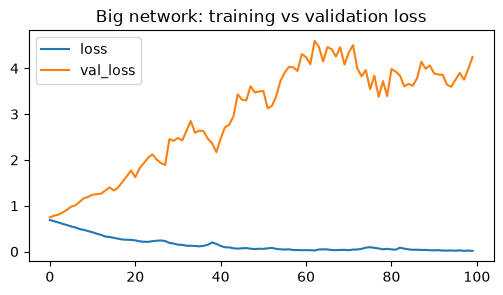

In [5]:
VALIDATION_FRACTION = 0.2
BATCH_SIZE = 64
EPOCHS = 3 if QUICK_RUN else 100
BIG_NETWORK = [256, 256, 256]


def build_model(hidden_units: list[int], dropout: float = 0.0, l2: float = 0.0,
                batch_norm: bool = False, learning_rate: float = 1e-3) -> keras.Model:
    """依照設定組出全連接網路：每一層 Dense → (BatchNorm) → ReLU → (Dropout)。"""
    keras.utils.set_random_seed(RANDOM_STATE)
    model = keras.Sequential([keras.Input(shape=(len(feature_names),))])
    for units in hidden_units:
        model.add(layers.Dense(units, kernel_regularizer=regularizers.l2(l2)))
        if batch_norm:
            model.add(layers.BatchNormalization())
        model.add(layers.Activation('relu'))
        if dropout:
            model.add(layers.Dropout(dropout))
    model.add(layers.Dense(1, activation='sigmoid'))
    model.compile(optimizer=keras.optimizers.Adam(learning_rate), loss='binary_crossentropy',
                  metrics=[keras.metrics.AUC(name='auc')])
    return model


def plot_history(history: keras.callbacks.History, title: str) -> None:
    pd.DataFrame(history.history)[['loss', 'val_loss']].plot(figsize=(6, 3), title=title)


big_model = build_model(BIG_NETWORK)
history = big_model.fit(X_train, y_train, validation_split=VALIDATION_FRACTION,
                        epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)
plot_history(history, 'Big network: training vs validation loss')

訓練 loss 一路下降，驗證 loss 卻很快就往上走：模型開始「背答案」，學到的是訓練資料的雜訊。

## 對策 1：Dropout

訓練時每一步隨機關掉一部分神經元，逼網路不能依賴少數特定的神經元。

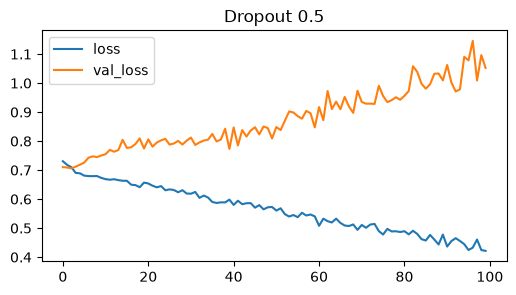

In [6]:
DROPOUT = 0.5

history = build_model(BIG_NETWORK, dropout=DROPOUT).fit(
    X_train, y_train, validation_split=VALIDATION_FRACTION, epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)
plot_history(history, f'Dropout {DROPOUT}')

## 對策 2：L2 正則化

在 loss 裡加上「權重越大、懲罰越大」，讓網路傾向用比較平滑、簡單的函數。

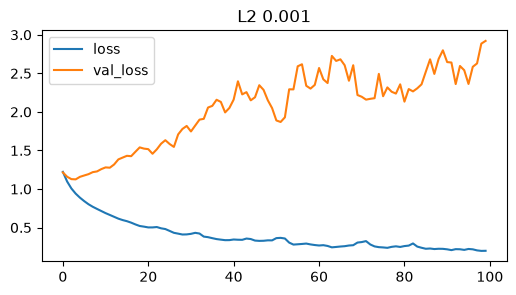

In [7]:
L2 = 1e-3

history = build_model(BIG_NETWORK, l2=L2).fit(
    X_train, y_train, validation_split=VALIDATION_FRACTION, epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)
plot_history(history, f'L2 {L2}')

## 對策 3：Batch Normalization

每一層的輸出先標準化再往下傳，訓練比較穩定，也可以用比較大的學習率。

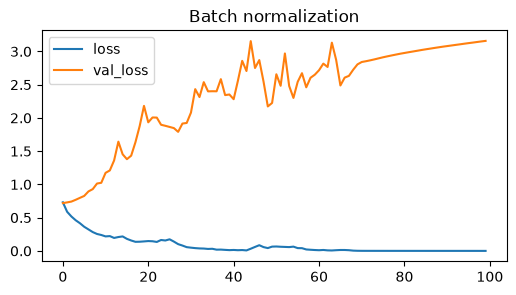

In [8]:
history = build_model(BIG_NETWORK, batch_norm=True).fit(
    X_train, y_train, validation_split=VALIDATION_FRACTION, epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)
plot_history(history, 'Batch normalization')

## 對策 4：Early Stopping

驗證 loss 連續 `PATIENCE` 個 epoch 沒有進步就停止訓練，並把權重還原成驗證 loss 最低的那一次。

在第 13 個 epoch 停止


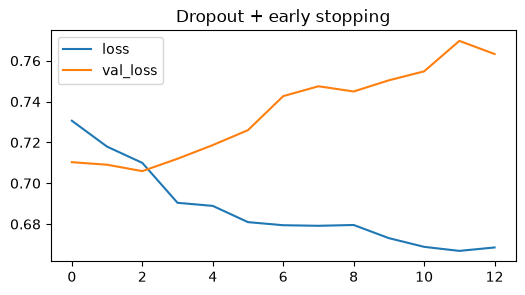

In [9]:
PATIENCE = 10


def early_stopping() -> keras.callbacks.EarlyStopping:
    return keras.callbacks.EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True)


history = build_model(BIG_NETWORK, dropout=DROPOUT).fit(
    X_train, y_train, validation_split=VALIDATION_FRACTION, epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=[early_stopping()], verbose=0)
plot_history(history, 'Dropout + early stopping')
print(f'在第 {len(history.history["loss"])} 個 epoch 停止')

## Part 2：比較多組設定

每組設定都用 Early Stopping 訓練，記錄**驗證資料**上的 AUC。
挑選設定只能看驗證資料；測試資料要留到最後，只用一次。

In [10]:
CONFIGS = {
    'small': dict(hidden_units=[32]),
    'small + dropout': dict(hidden_units=[32], dropout=0.3),
    'medium + dropout': dict(hidden_units=[128, 64], dropout=0.5),
    'medium + L2': dict(hidden_units=[128, 64], l2=1e-3),
    'medium + batch norm + dropout': dict(hidden_units=[128, 64], batch_norm=True, dropout=0.5),
    'deep + dropout + L2': dict(hidden_units=[256, 128, 64], dropout=0.5, l2=1e-4),
}

results, trained = {}, {}
for name, config in CONFIGS.items():
    model = build_model(**config)
    history = model.fit(X_train, y_train, validation_split=VALIDATION_FRACTION, epochs=EPOCHS,
                        batch_size=BATCH_SIZE, callbacks=[early_stopping()], verbose=0)
    trained[name] = model
    results[name] = {
        'best val AUC': max(history.history['val_auc']),
        'epochs': len(history.history['loss']),
    }

results = pd.DataFrame(results).T.sort_values('best val AUC', ascending=False)
results.style.format({'best val AUC': '{:.3f}', 'epochs': '{:.0f}'})

,best val AUC,epochs
small,0.520,12
medium + dropout,0.491,12
small + dropout,0.485,11
deep + dropout + L2,0.481,14
medium + batch norm + dropout,0.458,13
medium + L2,0.434,11


如果每一組的驗證 AUC 都在 0.5 附近，代表這組特徵對未來 10 天的漲跌幾乎沒有預測力，換更複雜的網路也救不了；
這時該改善的是特徵與問題設定，而不是網路結構。

## 用最好的設定回測測試期間

最佳設定：small，測試 AUC：0.507


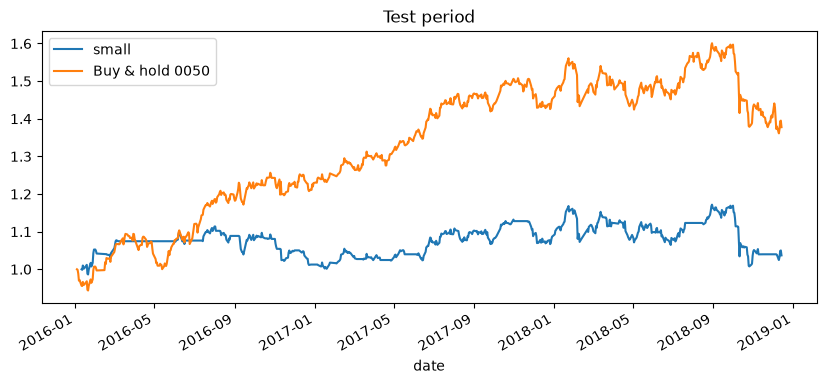

In [11]:
SIGNAL_QUANTILE = 0.7

best_name = results.index[0]
best_model = trained[best_name]

train_probability = pd.Series(best_model.predict(X_train, verbose=0).ravel(), index=train.index)
test_probability = pd.Series(best_model.predict(X_test, verbose=0).ravel(), index=test.index)
print(f'最佳設定：{best_name}，測試 AUC：{roc_auc_score(y_test, test_probability):.3f}')

threshold = train_probability.quantile(SIGNAL_QUANTILE)
hold = (test_probability > threshold).rolling(HORIZON, min_periods=1).max().astype(bool)
position = hold.to_frame(TRADE_STOCK)

strategy = sim(position, name=best_name, tax_ratio=ETF_TAX_RATIO)
buy_and_hold = sim(position.notna(), name='Buy & hold 0050', tax_ratio=ETF_TAX_RATIO)

pd.DataFrame({best_name: strategy.creturn, 'Buy & hold 0050': buy_and_hold.creturn}).plot(
    figsize=(10, 4), title='Test period');

In [12]:
pd.DataFrame({
    name: {key: report.get_stats()[key] for key in ['cagr', 'max_drawdown', 'daily_sharpe']}
    for name, report in [(best_name, strategy), ('Buy & hold 0050', buy_and_hold)]
}).T.style.format({'cagr': '{:.2%}', 'max_drawdown': '{:.2%}', 'daily_sharpe': '{:.2f}'})

,cagr,max_drawdown,daily_sharpe
small,1.25%,-14.00%,-0.00
Buy & hold 0050,11.50%,-14.96%,0.72
